# Mean Reversion Statistical Arbitrage Strategy
### End-to-End Quantitative Pipeline (Clustering, Cointegration, Vasicek Model, Backtesting, Consistency Analysis, & Multi-Pair Portfolio Benchmarking)

This notebook implements the complete statistical arbitrage workflow:
1. **Step 1: Clustering Top 100 Stocks**: Extracting factor returns via PCA and grouping assets using return correlation distance $D_{ij} = \sqrt{2(1 - \rho_{ij})}$.
2. **Step 2: Cointegration & Stationarity Testing**: Testing intra-cluster pairs using Engle-Granger cointegration and Augmented Dickey-Fuller (ADF) tests.
3. **Step 3: Vasicek (Ornstein-Uhlenbeck) Model**: Parameter estimation (reversion speed $\kappa$, long-term mean $\theta$, volatility $\sigma$, and half-life $t_{1/2}$) for the continuous stochastic process.
4. **Step 4: Trade Performance at Different Deviations**: Parameter sweep over entry threshold $z_{entry} \in [1.0, 1.5, 2.0, 2.5, 3.0]$ standard deviations from mean $\theta$.
5. **Step 5: Advanced Exit Management & Strategy Backtest**: Executing single-pair backtests with position exit rules: mean reversion ($z = 0$), stop-loss breach ($z \ge 3.5$), or max duration expiry ($T_{max} = 20$ days).
6. **Step 6: Full-Universe Out-of-Sample Dickey-Fuller Consistency**: Evaluates whether cointegrated stationary pairs remain stationary out-of-sample across the universe.
7. **Step 7: ADF-Weighted Multi-Pair Portfolio Backtest vs. SPX Benchmark**: Scaling to an institutional multi-pair portfolio with ADF-weighted capital allocation ($w_i \propto |t_{\text{ADF}, i}|$),
 threshold-based rebalancing ($\tau = 5\%$), and out-of-sample performance evaluation against the S&P 500 (`^GSPC`) benchmark.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cluster import fetch_top_100_data, cluster_assets, extract_features, get_cluster_groups
from src.cointegration import find_cointegrated_pairs, test_stationarity_consistency, calculate_spread, evaluate_universe_df_consistency
from src.strategy import fit_vasicek_model, simulate_vasicek, generate_vasicek_signals
from src.backtest import run_pair_backtest, sweep_entry_deviations

# Visual Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('All statistical arbitrage modules loaded successfully!')

All statistical arbitrage modules loaded successfully!


--- 
## 1. Step 1: Asset Clustering (Top 100 Equities)
We fetch daily historical price data for the Top 100 equities, extract return features & PCA factors, and cluster them using return correlation distances.

In [2]:
prices = fetch_top_100_data()
print(f'Retrieved price matrix: {prices.shape[1]} tickers x {prices.shape[0]} daily timestamps.')
prices.head()

Loaded 100 tickers and 2514 dates from cache: data/top_100_prices.csv
Retrieved price matrix: 100 tickers x 2514 daily timestamps.


,AAPL,ABBV,ABT,ACN,ADBE,ADP,AMAT,AMD,AMGN,AMT,...,TXN,UNH,UNP,V,VZ,WFC,WM,WMT,XOM,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2016-08-01,24.142248,44.405243,37.518318,95.349831,97.720001,71.255760,23.555910,6.64,129.254761,90.724686,...,53.169773,121.680717,74.622467,72.935875,31.821640,36.221382,55.516666,20.718460,55.627785,46.169407
2016-08-02,23.784840,44.299095,37.336071,95.307564,96.050003,70.693230,23.286907,6.26,129.247269,90.492142,...,52.386093,121.392418,73.211166,72.954506,31.529697,36.138058,55.207680,20.535929,56.392288,45.546482
2016-08-03,24.083054,44.159809,37.236660,95.966476,96.669998,70.870041,23.493141,6.30,128.712982,89.709221,...,52.408901,121.146591,74.470100,73.355217,31.471300,36.328972,54.965496,20.482578,56.683834,46.911423
2016-08-04,24.231833,43.848015,37.120686,96.050926,97.089996,71.046814,23.645582,6.47,128.148941,90.244087,...,52.964333,121.002380,74.309731,74.072861,31.488819,36.535164,54.932098,20.583666,56.677368,47.094624
2016-08-05,24.600330,44.139900,37.493458,96.802704,99.040001,72.059364,24.040115,6.61,128.883636,90.368103,...,53.375206,121.239815,75.255943,74.687935,31.319492,37.176670,55.090778,20.712847,56.729195,46.801487


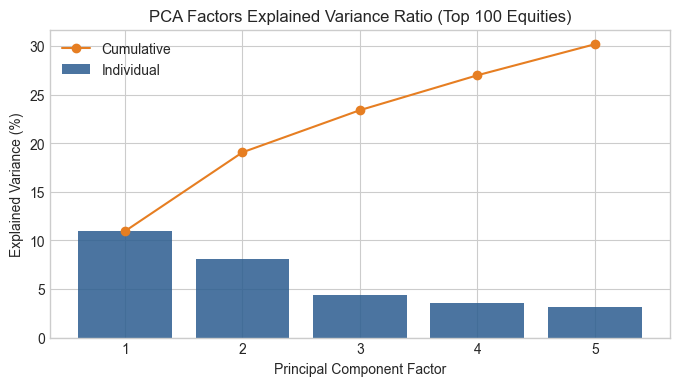

In [3]:
# Extract PCA Features & Plot Variance Structure
feature_df, pca = extract_features(prices, n_components=5)
explained_var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained_var)+1), explained_var * 100, color='#2b5c8f', alpha=0.85, label='Individual')
ax.plot(range(1, len(explained_var)+1), np.cumsum(explained_var) * 100, color='#e67e22', marker='o', label='Cumulative')
ax.set_title('PCA Factors Explained Variance Ratio (Top 100 Equities)')
ax.set_xlabel('Principal Component Factor')
ax.set_ylabel('Explained Variance (%)')
ax.legend()
plt.show()

Cluster Sizes Distribution:
Cluster
3    60
2    15
1     9
6     5
4     4
7     2
0     2
9     1
8     1
5     1
Name: count, dtype: int64


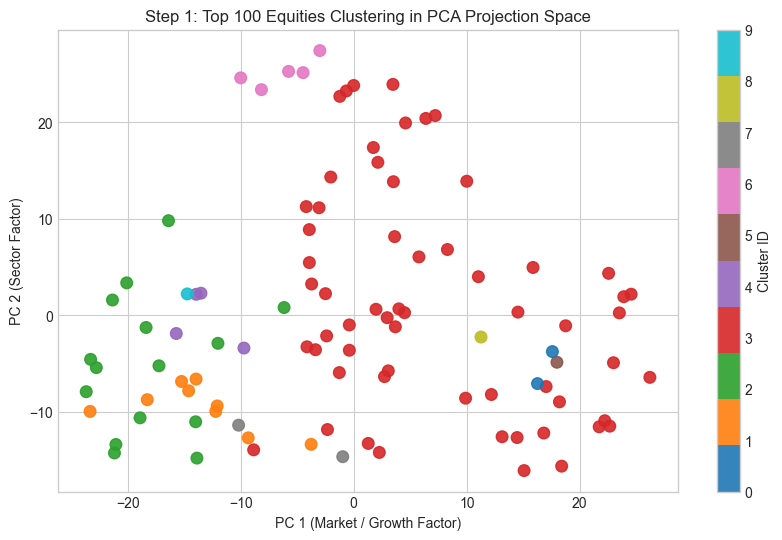

In [4]:
# Run Agglomerative Clustering on correlation distances
clusters = cluster_assets(prices, method='agglomerative', n_clusters=10)
print('Cluster Sizes Distribution:')
print(clusters['Cluster'].value_counts())

# Visualize clusters in PCA space
plt.figure(figsize=(10, 6))
scatter = plt.scatter(feature_df['PC_1'], feature_df['PC_2'], c=clusters['Cluster'], cmap='tab10', s=70, alpha=0.9)
plt.colorbar(scatter, label='Cluster ID')
plt.title('Step 1: Top 100 Equities Clustering in PCA Projection Space')
plt.xlabel('PC 1 (Market / Growth Factor)')
plt.ylabel('PC 2 (Sector Factor)')
plt.grid(True)
plt.show()

--- 
## 2. Step 2: Cointegration & Stationarity Testing
We test intra-cluster pairs using the Engle-Granger two-step test ($Y_t = \beta X_t + \alpha + \epsilon_t$) and Augmented Dickey-Fuller (ADF) test on the residual spread.

In [5]:
# Find cointegrated pairs within clusters
coint_df = find_cointegrated_pairs(prices, cluster_df=clusters, p_value_threshold=0.05)
print(f'Discovered {len(coint_df)} cointegrated pairs (p <= 0.05).')
coint_df.head(10)

Testing cointegration across 1929 intra-cluster pair candidates...
Discovered 153 cointegrated pairs (p <= 0.05).


,Stock_Y,Stock_X,Beta,Alpha,Coint_PValue,ADF_Stat,ADF_PValue,Spread_Std
0,CAT,KLAC,4.013515,62.745912,0.000001,-8.286819,4.368105e-13,27.879653
1,QCOM,SHW,0.494987,-5.276877,0.000001,-4.437532,2.545811e-04,17.433150
2,HD,SPGI,0.716921,30.792477,0.000007,-5.855172,3.513857e-07,17.225718
3,CDNS,LIN,0.816505,-67.712272,0.000031,-5.781070,5.124444e-07,20.196169
4,HD,QCOM,1.737282,64.936034,0.000035,-4.093389,9.931823e-04,34.414859
5,BKNG,IBM,0.758484,1.500114,0.000046,-4.829985,4.764021e-05,15.368313
6,AMD,GOOGL,1.056711,-30.868339,0.000069,-2.993600,3.549644e-02,35.318469
7,AMAT,AMD,1.065216,18.771431,0.000076,-4.443697,2.482107e-04,26.613088
8,LOW,QCOM,1.300023,18.721174,0.000080,-4.107228,9.422218e-04,25.574055
9,QCOM,SPGI,0.355104,-2.211947,0.000094,-4.081723,1.038135e-03,18.851358


--- 
## 3. Vasicek (Ornstein-Uhlenbeck) Process Modeling
Continuous stochastic process formulation:
$$dS_t = \kappa (\theta - S_t) dt + \sigma dW_t$$

Discrete AR(1) translation ($S_t = a + b S_{t-1} + \epsilon_t$):
- **Reversion Speed**: $\kappa = -\frac{\ln(b)}{\Delta t}$
- **Equilibrium Mean**: $\theta = \frac{a}{1 - b}$
- **Volatility**: $\sigma = \sigma_\epsilon \sqrt{\frac{-2 \ln(b)}{\Delta t (1 - b^2)}}$
- **Half-Life**: $t_{1/2} = \frac{\ln(2)}{\kappa}$

In [6]:
top_pair = coint_df.iloc[0]
stock_y = top_pair['Stock_Y']
stock_x = top_pair['Stock_X']
print(f'Selected Candidate Pair: {stock_y} (Y) vs {stock_x} (X)')

spread, beta, alpha = calculate_spread(prices[stock_y], prices[stock_x])
v_params = fit_vasicek_model(spread)

print('=== Fitted Vasicek Parameters ===')
for k, v in v_params.items():
    print(f'{k:20s}: {v:.6f}' if isinstance(v, float) else f'{k:20s}: {v}')

Selected Candidate Pair: CAT (Y) vs KLAC (X)
=== Fitted Vasicek Parameters ===
kappa               : 0.042201
theta               : 0.390644
sigma               : 8.097201
half_life           : 16.424711
ar1_a               : 0.016143
ar1_b               : 0.958677
residual_std        : 7.929311
r_squared           : 0.919152


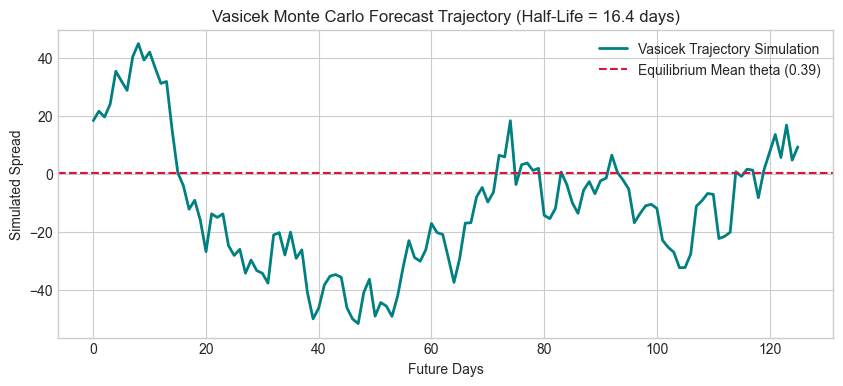

In [7]:
# Simulate Vasicek Monte Carlo Trajectory
simulated_spread = simulate_vasicek(
    theta=v_params['theta'],
    kappa=v_params['kappa'],
    sigma=v_params['sigma'],
    state_0=spread.iloc[-1],
    dt=1.0,
    n_steps=126,
    seed=42
)

plt.figure(figsize=(10, 4))
plt.plot(range(126), simulated_spread, color='#008080', lw=2, label='Vasicek Trajectory Simulation')
plt.axhline(v_params['theta'], color='crimson', linestyle='--', label=f'Equilibrium Mean theta ({v_params["theta"]:.2f})')
plt.title(f'Vasicek Monte Carlo Forecast Trajectory (Half-Life = {v_params["half_life"]:.1f} days)')
plt.xlabel('Future Days')
plt.ylabel('Simulated Spread')
plt.legend()
plt.grid(True)
plt.show()

--- 
## 4. Trade Performance at Different Deviations from the Mean
Evaluating strategy performance across multiple entry threshold deviations ($z_{entry} \in [1.0, 1.5, 2.0, 2.5, 3.0]$ standard deviations from mean $\theta$).

Entry Deviation Sweep Results:


,Entry_Dev_Z,Total_Return_%,Sharpe_Ratio,Max_Drawdown_%,Total_Trades,Win_Rate_%,Avg_Holding_Days,Profit_Factor
0,1.0,83.113432,1.259933,-12.263851,48,54.166667,10.041667,3.177279
1,1.5,52.852655,1.018105,-10.302281,41,51.219512,7.780488,2.415853
2,2.0,28.002110,0.647848,-10.417028,35,45.714286,6.285714,2.053743
3,2.5,22.558732,0.552126,-8.876818,32,43.750000,5.093750,1.986910
4,3.0,5.572243,0.008340,-8.721294,29,41.379310,4.103448,1.331639


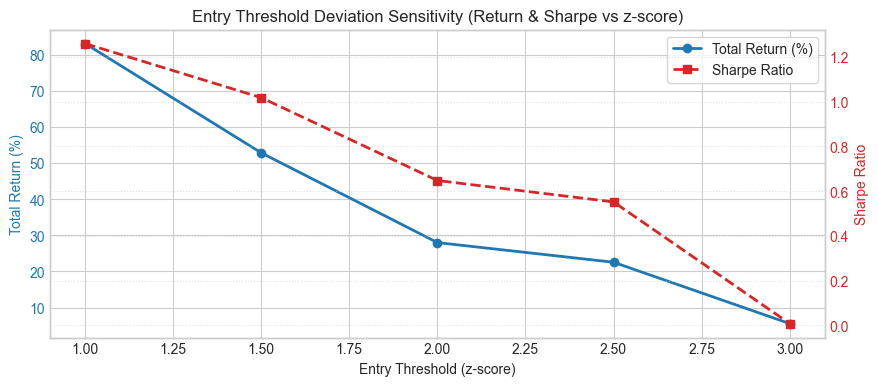

In [8]:
sweep_df = sweep_entry_deviations(
    prices=prices,
    stock_y=stock_y,
    stock_x=stock_x,
    vasicek_params=v_params,
    deviations=[1.0, 1.5, 2.0, 2.5, 3.0],
    stop_z=3.5,
    max_holding_days=int(min(100, 2 * v_params['half_life'])) if np.isfinite(v_params['half_life']) else 20
)
print('Entry Deviation Sweep Results:')
display(sweep_df)

fig, ax1 = plt.subplots(figsize=(10, 4))
color = 'tab:blue'
ax1.set_xlabel('Entry Threshold (z-score)')
ax1.set_ylabel('Total Return (%)', color=color)
line1 = ax1.plot(sweep_df['Entry_Dev_Z'], sweep_df['Total_Return_%'], marker='o', color=color, lw=2, label='Total Return (%)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Sharpe Ratio', color=color)
line2 = ax2.plot(sweep_df['Entry_Dev_Z'], sweep_df['Sharpe_Ratio'], marker='s', color=color, linestyle='--', lw=2, label='Sharpe Ratio')
ax2.tick_params(axis='y', labelcolor=color)

# Combine handles & labels for legend displaying both slopes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.title('Entry Threshold Deviation Sensitivity (Return & Sharpe vs z-score)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


--- 
## 5. Advanced Exit Management & Strategy Backtest
Executing backtest with position exit rules:
1. **Mean Reversion**: Reaching equilibrium mean $\theta$ ($z = 0$).
2. **Stop Loss**: Spread moving past stop threshold ($z_{stop} = 3.5$).
3. **Max Duration Expiry**: Holding time exceeding $T_{max} = 20$ days.

In [9]:
equity_signals, trades_df, summary_metrics = run_pair_backtest(
    prices=prices,
    stock_y=stock_y,
    stock_x=stock_x,
    vasicek_params=v_params,
    entry_z=2.0,
    stop_z=3.5,
    max_holding_days=20
)

print('=== Backtest Performance Summary ===')
for k, v in summary_metrics.items():
    if k != 'Exit_Reasons':
        print(f'{k:22s}: {v:.4f}' if isinstance(v, float) else f'{k:22s}: {v}')

print('\nExit Breakdown:', summary_metrics['Exit_Reasons'])
if not trades_df.empty:
    display(trades_df.head(10))

=== Backtest Performance Summary ===
Total_Return          : 0.2793
Annualized_Return     : 0.0857
Annualized_Vol        : 0.1094
Sharpe_Ratio          : 0.6264
Sortino_Ratio         : 0.8752
Max_Drawdown          : -0.0986
Total_Trades          : 37
Win_Rate              : 0.5135
Avg_Trade_Return      : 0.0069
Avg_Holding_Days      : 5.5946
Profit_Factor         : 1.9738

Exit Breakdown: {'Stop_Loss': 26, 'Max_Duration': 6, 'Mean_Reversion': 5}


,Stock_Y,Stock_X,Entry_Date,Exit_Date,Position,Entry_Z,Exit_Z,Entry_Spread,Exit_Spread,Return,Holding_Days,Exit_Reason
0,CAT,KLAC,2024-06-12,2024-07-12,Long,-2.010176,-2.169916,-55.635423,-60.087575,-0.010548,20,Max_Duration
1,CAT,KLAC,2024-10-16,2024-11-13,Short,2.228064,2.555714,62.489501,71.621525,-0.020230,20,Max_Duration
2,CAT,KLAC,2024-11-14,2024-12-13,Short,2.559892,2.177966,71.737961,61.093228,0.015204,20,Max_Duration
3,CAT,KLAC,2024-12-16,2025-01-16,Short,2.090357,0.926649,58.651444,26.217495,0.052876,20,Max_Duration
4,CAT,KLAC,2025-01-27,2025-02-12,Short,2.081344,-0.073671,58.400252,-1.662664,0.094882,12,Mean_Reversion
5,CAT,KLAC,2025-10-14,2025-10-27,Short,2.489067,-0.026583,69.763995,-0.350245,0.075999,9,Mean_Reversion
6,CAT,KLAC,2025-11-14,2025-12-15,Short,2.024975,2.046670,56.829162,57.433842,-0.002560,20,Max_Duration
7,CAT,KLAC,2025-12-16,2026-01-15,Short,2.040582,-0.227669,57.264169,-5.954774,0.056047,20,Mean_Reversion
8,CAT,KLAC,2026-02-02,2026-02-03,Short,3.207033,4.377234,89.774568,122.389526,-0.027731,1,Stop_Loss
9,CAT,KLAC,2026-02-04,2026-02-05,Short,4.634472,3.829824,129.559050,107.132536,0.017971,1,Stop_Loss


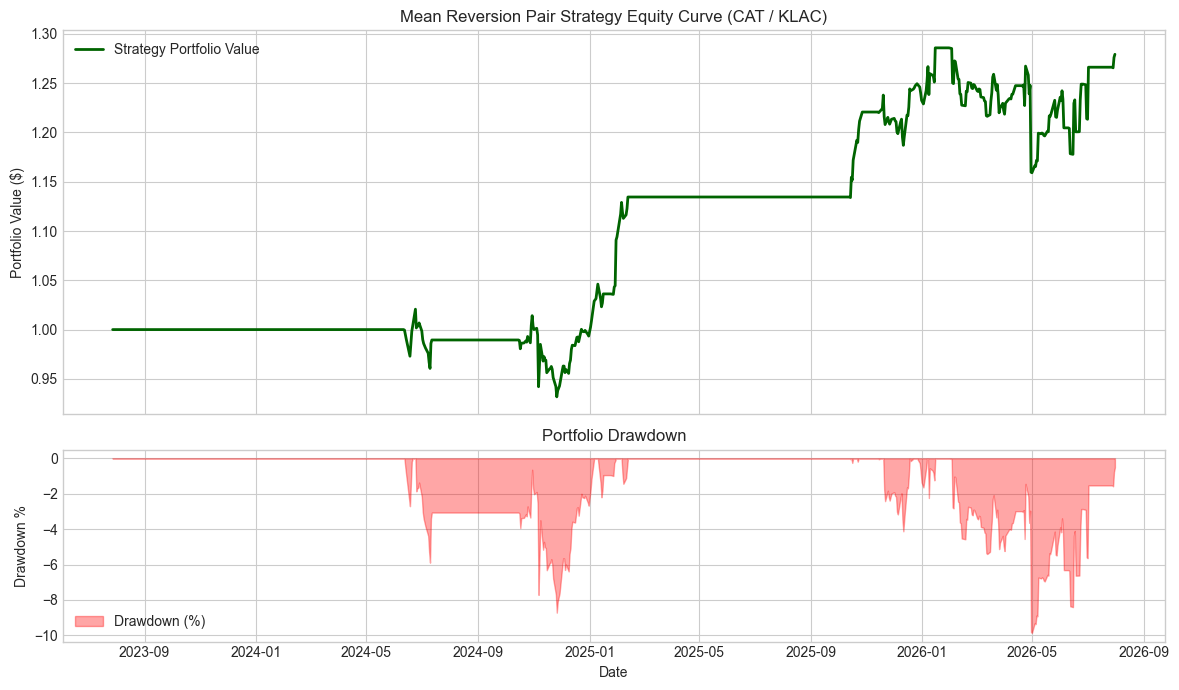

In [10]:
# Plot Equity Curve & Drawdowns
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(equity_signals.index, equity_signals['Equity'], color='darkgreen', lw=2, label='Strategy Portfolio Value')
ax1.set_title(f'Mean Reversion Pair Strategy Equity Curve ({stock_y} / {stock_x})')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend(loc='upper left')
ax1.grid(True)

cum_max = equity_signals['Equity'].cummax()
drawdown = (equity_signals['Equity'] - cum_max) / cum_max
ax2.fill_between(equity_signals.index, drawdown * 100, 0, color='red', alpha=0.35, label='Drawdown (%)')
ax2.set_title('Portfolio Drawdown')
ax2.set_ylabel('Drawdown %')
ax2.set_xlabel('Date')
ax2.legend(loc='lower left')
ax2.grid(True)

plt.tight_layout()
plt.show()

--- 
## 6. Full-Universe Out-of-Sample Dickey-Fuller Consistency Analysis
Evaluating whether pairs that test stationary in-sample remain stationary out-of-sample across the entire universe.

=== Universe Out-of-Sample Stationarity Consistency Summary ===
Total_Evaluated               : 50
Consistent_Count              : 26
Consistency_Rate_%            : 52.0000
Retained_Stationarity_Count   : 6
Retained_Stationarity_Rate_%  : 12.0000
Avg_InSample_PValue           : 0.1297
Avg_OutSample_PValue          : 0.1836


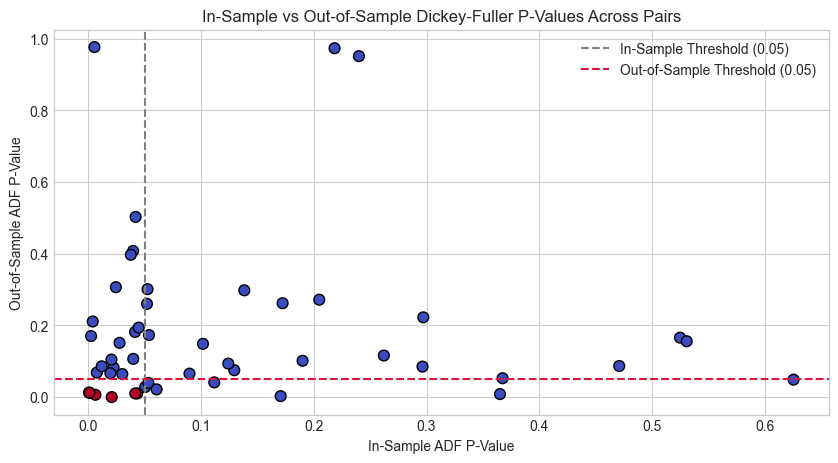

In [11]:
cons_df, cons_summary = evaluate_universe_df_consistency(
    prices=prices,
    cointegrated_pairs_df=coint_df,
    train_ratio=0.7,
    max_pairs_eval=50
)

print('=== Universe Out-of-Sample Stationarity Consistency Summary ===')
for k, v in cons_summary.items():
    print(f'{k:30s}: {v:.4f}' if isinstance(v, float) else f'{k:30s}: {v}')

# Visual Plot of In-Sample vs Out-of-Sample P-Values
if not cons_df.empty:
    plt.figure(figsize=(10, 5))
    plt.scatter(cons_df['InSample_ADF_PValue'], cons_df['OutSample_ADF_PValue'], c=cons_df['Retained_Stationarity'], cmap='coolwarm', s=60, edgecolors='k')
    plt.axvline(0.05, color='gray', linestyle='--', label='In-Sample Threshold (0.05)')
    plt.axhline(0.05, color='crimson', linestyle='--', label='Out-of-Sample Threshold (0.05)')
    plt.title('In-Sample vs Out-of-Sample Dickey-Fuller P-Values Across Pairs')
    plt.xlabel('In-Sample ADF P-Value')
    plt.ylabel('Out-of-Sample ADF P-Value')
    plt.legend()
    plt.grid(True)
    plt.show()

---
## 7. Step 7: ADF-Weighted Multi-Pair Portfolio Backtest vs. S&P 500 (SPX) Benchmark
In this section, we scale from a single-pair strategy to an institutional **multi-pair statistical arbitrage portfolio**:
1. **Pair Selection**: Filter top distinct, non-overlapping cointegrated pairs from intra-cluster Engle-Granger tests, sorted by ADF stationarity significance ($t_{\text{ADF}}$).
2. **ADF-Weighted Capital Allocation**: Capital is allocated to active pairs in proportion to their ADF statistic magnitude ($w_i \propto |t_{\text{ADF}, i}|$).
3. **Threshold-Based Rebalancing**: Rebalancing occurs **only** when active pair positions enter/exit or when target weight drift exceeds $\tau_{\text{rebalance}} = 5\%$, preventing excessive turnover costs.
4. **Out-of-Sample SPX Benchmark Comparison**: Strategy performance is evaluated **strictly out-of-sample** against a Buy & Hold S&P 500 (`^GSPC`) benchmark matching the exact out-of-sample datetime index, measuring Sharpe ratio, Max Drawdown, Beta, Jensen's Alpha, and Correlation.


=== Top 10 Distinct Cointegrated Pairs (ADF-Sorted) ===


,Stock_Y,Stock_X,Beta,ADF_Stat,ADF_PValue
0,CAT,KLAC,4.013515,-8.286819,4.368105e-13
1,HD,SPGI,0.716921,-5.855172,3.513857e-07
2,CDNS,LIN,0.816505,-5.781070,5.124444e-07
3,APH,GS,0.160089,-5.352999,4.248570e-06
4,IBM,NVDA,0.919092,-5.022878,1.999209e-05
5,MSFT,SYK,1.600048,-4.709617,8.072115e-05
6,HON,TXN,0.747824,-4.591791,1.337453e-04
7,AMAT,AMD,1.065216,-4.443697,2.482107e-04
8,QCOM,SHW,0.494987,-4.437532,2.545811e-04
9,ETN,TJX,2.915112,-4.407058,2.884102e-04



=== Stat Arb Multi-Pair Portfolio vs SPX Buy & Hold (Out-of-Sample Only) ===


,Metric,Stat_Arb_Portfolio,SPX_Benchmark
0,Total Return (%),63.35%,63.45%
1,Annualized Return (%),17.80%,17.82%
2,Annualized Volatility (%),8.05%,15.06%
3,Sharpe Ratio,1.83,1.03
4,Sortino Ratio,3.44,1.53
5,Max Drawdown (%),-4.23%,-18.90%
6,Beta to SPX,-0.057,1.000
7,Correlation to SPX,-0.106,1.000
8,Jensen's Alpha (%),16.69%,0.00%
9,Total Rebalances Count,625,N/A


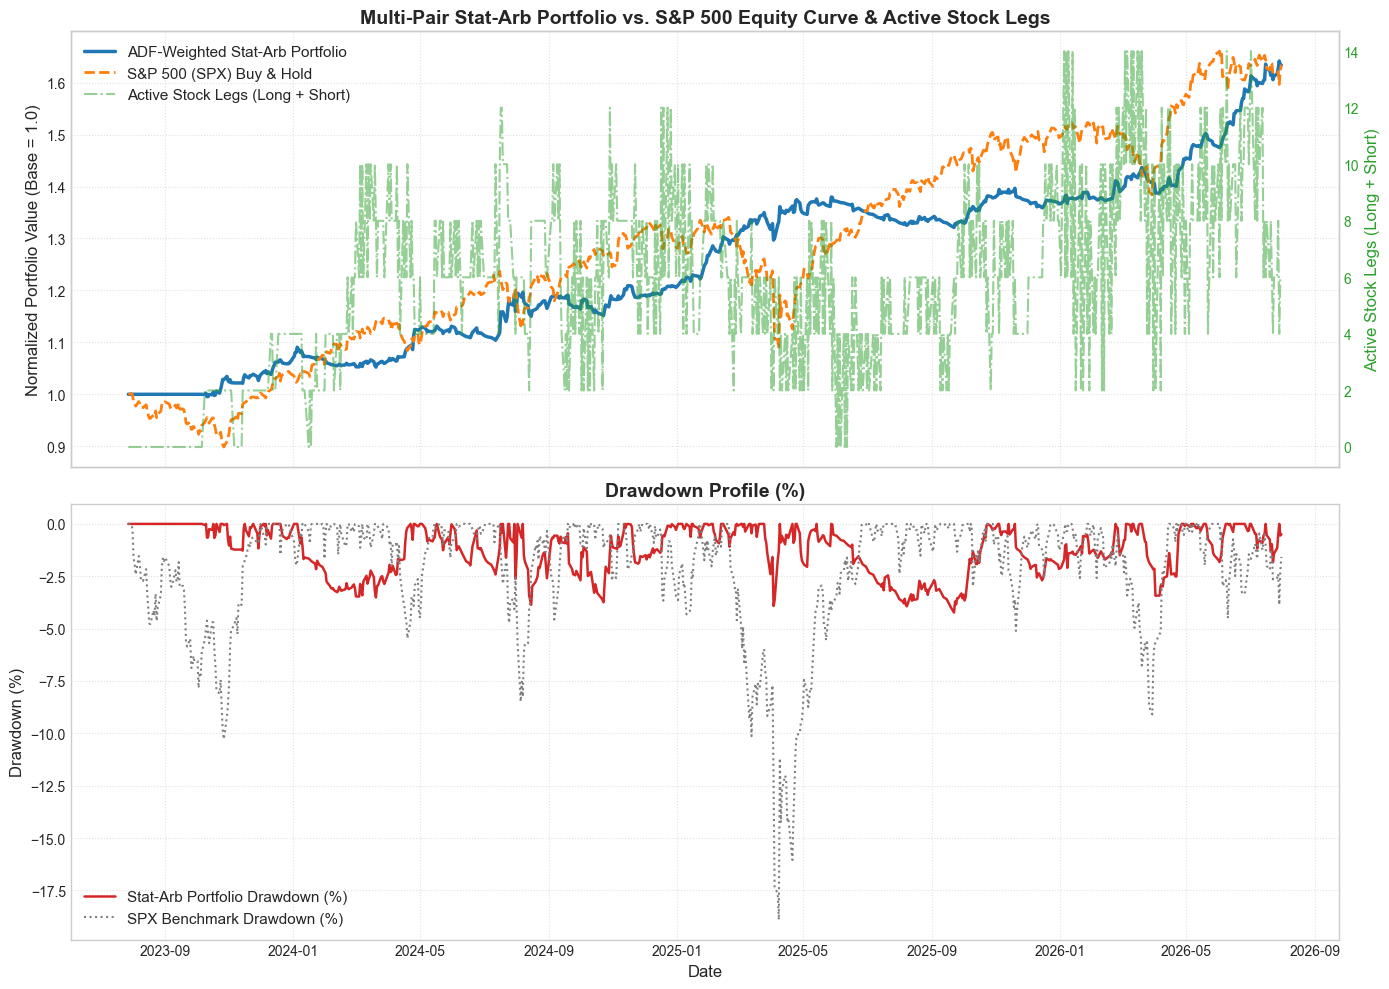

In [12]:
from src.cointegration import select_top_distinct_pairs
from src.backtest import run_multi_pair_portfolio_backtest, fetch_spx_benchmark, calculate_portfolio_vs_benchmark_metrics

# 1. Select top 10 distinct cointegrated pairs sorted by ADF stat
top_distinct_pairs = select_top_distinct_pairs(coint_df, max_pairs=10, allow_stock_reuse=False)

print('=== Top 10 Distinct Cointegrated Pairs (ADF-Sorted) ===')
display(top_distinct_pairs[['Stock_Y', 'Stock_X', 'Beta', 'ADF_Stat', 'ADF_PValue']])

# 2. Run Multi-Pair Portfolio Backtest with ADF-Weighting & Threshold Rebalancing
port_df, trades_df, port_metrics = run_multi_pair_portfolio_backtest(
    prices=prices,
    selected_pairs_df=top_distinct_pairs,
    entry_z=3.0,
    stop_z=3.5,
    max_holding_days=20,
    transaction_cost=0.0005,
    rebalance_threshold=0.05,
    train_ratio=0.7,
    use_out_of_sample_only=True
)

# 3. Fetch SPX Benchmark Equity (Matching Out-of-Sample Datetime Index)
spx_equity = fetch_spx_benchmark(port_df.index, ticker='^GSPC')

# 4. Calculate Comparative Metrics
comparison_results = calculate_portfolio_vs_benchmark_metrics(
    portfolio_equity=port_df['Equity'],
    benchmark_equity=spx_equity,
    trades_df=trades_df,
    rebalance_count=port_metrics['Rebalance_Count'],
    total_rebalance_costs=port_metrics['Total_Rebalance_Costs']
)

print('\n=== Stat Arb Multi-Pair Portfolio vs SPX Buy & Hold (Out-of-Sample Only) ===')
display(comparison_results['comparison_df'])

# 5. Visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Equity Curve Comparison & Active Stock Legs
axes[0].plot(port_df.index, port_df['Equity'], label='ADF-Weighted Stat-Arb Portfolio', color='#1f77b4', linewidth=2.5)
axes[0].plot(spx_equity.index, spx_equity, label='S&P 500 (SPX) Buy & Hold', color='#ff7f0e', linestyle='--', linewidth=2.0)
axes[0].set_title('Multi-Pair Stat-Arb Portfolio vs. S&P 500 Equity Curve & Active Stock Legs', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized Portfolio Value (Base = 1.0)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Secondary Y-Axis for Active Stock Legs (Number of Stocks Long + Number of Stocks Shorted)
ax0_twin = axes[0].twinx()
ax0_twin.plot(port_df.index, port_df['Active_Legs'], label='Active Stock Legs (Long + Short)', color='#2ca02c', linestyle='-.', linewidth=1.5, alpha=0.5)
ax0_twin.set_ylabel('Active Stock Legs (Long + Short)', fontsize=12, color='#2ca02c')
ax0_twin.tick_params(axis='y', labelcolor='#2ca02c')
ax0_twin.grid(False)

# Combined Legend for Primary and Secondary Axes
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

# Active Pairs & Drawdowns
cum_max_port = port_df['Equity'].cummax()
dd_port = (port_df['Equity'] - cum_max_port) / cum_max_port * 100
cum_max_spx = spx_equity.cummax()
dd_spx = (spx_equity - cum_max_spx) / cum_max_spx * 100

axes[1].plot(dd_port.index, dd_port, label='Stat-Arb Portfolio Drawdown (%)', color='#d62728', linewidth=1.8)
axes[1].plot(dd_spx.index, dd_spx, label='SPX Benchmark Drawdown (%)', color='#7f7f7f', linestyle=':', linewidth=1.5)
axes[1].set_title('Drawdown Profile (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend(loc='lower left', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
